# **<span style="color: #87CEEB;">PixelCNN: Autoregressive Image Generation</span>**


<h1><b> Part 1: PixelCNN Implementation using TensorFlow </b></h1>

## **Introduction**
This assignment explores **PixelCNN**, a deep learning model designed for **generating images pixel-by-pixel** using **autoregressive modeling**. We apply this model to the **MNIST dataset**, which consists of handwritten digits, to understand how PixelCNN learns pixel dependencies and generates realistic digit images.

## **Research Goals**
- Implement **PixelCNN** using TensorFlow/Keras.  
- Preprocess the **MNIST dataset** for binary pixel values.  
- Define custom **Pixel Convolutional Layers** and **Residual Blocks**.  
- Train the model to **generate images sequentially pixel by pixel**.  
- Evaluate model performance and visualize generated images.  

## **Dataset**
The **MNIST dataset** contains:
- **60,000 training images**  
- **10,000 testing images**  
Each image is **28×28 pixels** and represents a digit from **0 to 9**.

### Import Necessary Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from IPython.display import Image, display
from tqdm import tqdm_notebook

### Visualize the Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


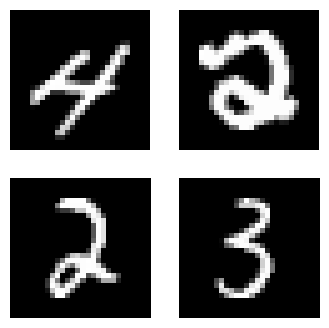

In [ ]:
def load_and_plot(num_samples):
    """
    TODO: Load the MNIST dataset, print the dataset shapes and plot a grid of random images from the training set.

    Parameters:
    num_samples (int): Number of images to plot in a grid.
    """
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    print("Training set shape:", x_train.shape)
    print("Test set shape:", x_test.shape)

    indices = np.random.choice(x_train.shape[0], num_samples, replace=False)
    sample_images = x_train[indices]

    grid_size = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size*2, grid_size*2))
    axes = axes.flatten()

    for i in range(num_samples):
        axes[i].imshow(sample_images[i], cmap='gray')
        axes[i].axis('off')
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.show()

load_and_plot(4)

### Preprocess the Dataset  

- Apply **binarization** to the images: Convert pixel values to either 0 or 1 based on a chosen threshold.  
- Convert the dataset to **float32** for compatibility with the model.  
- Reshape the dataset to include a **single channel** for grayscale images.  
- Print the **shapes** of the training and testing datasets to verify the preprocessing steps.  


In [ ]:
# your code here
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255.0
x_test /= 255.0

x_train = (x_train >= 0.5).astype('float32')
x_test = (x_test >= 0.5).astype('float32')

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (60000, 28, 28, 1)
Test set shape: (10000, 28, 28, 1)


### Implement `PixelConv` Class

1. **Initialize the Layer:**  
   - Define a convolutional layer with the given parameters.  
   - Store the mask type ('A' or 'B') as an instance variable.  

2. **Create a Mask in the `setup_layer` Method:**  
   - Generate a mask matrix that ensures autoregressive pixel dependencies.  
   - Implement different masking rules for **Mask Type A and Mask Type B**.  

3. **Apply the Mask in the `apply_mask` Method:**  
   - Multiply the convolution kernel with the mask before computing outputs.  
   - Ensure the layer respects the masked constraints during forward pass.  


In [ ]:
import tensorflow as tf
import numpy as np

class PixelConv(tf.keras.layers.Layer):
    def __init__(self, mask_type, filters, kernel_size, **kwargs):
        super(PixelConv, self).__init__()
        self.mask_type = mask_type
        self.filters = filters
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(filters, kernel_size, padding='same', **kwargs)
        self.mask = None

    def build(self, input_shape):
        self.conv.build(input_shape)
        self.setup_layer(input_shape)
        super(PixelConv, self).build(input_shape)

    def setup_layer(self, input_shape):
        kernel_shape = self.conv.kernel.shape
        mask_np = np.ones(kernel_shape, dtype=np.float32)
        k_h, k_w = kernel_shape[0], kernel_shape[1]
        center_h, center_w = k_h // 2, k_w // 2

        if self.mask_type == 'A':
            mask_np[center_h, center_w:] = 0
        else:
            mask_np[center_h, center_w+1:] = 0

        mask_np[center_h+1:, :] = 0
        self.mask = self.add_weight(
            name="mask",
            shape=kernel_shape,
            initializer=tf.constant_initializer(mask_np),
            trainable=False
        )
        return

    def apply_mask(self, inputs):
        masked_kernel = self.conv.kernel * self.mask
        strides = [1, self.conv.strides[0], self.conv.strides[1], 1]
        outputs = tf.nn.conv2d(inputs, masked_kernel, strides=strides, padding='SAME')
        if self.conv.use_bias:
            outputs = tf.nn.bias_add(outputs, self.conv.bias)
        if self.conv.activation is not None:
            outputs = self.conv.activation(outputs)
        return outputs

    def call(self, inputs):
        return self.apply_mask(inputs)


### Implement a Residual Block for PixelCNN

A residual block helps improve training stability and allows better gradient flow by adding shortcut connections. In this class, you will define a residual block using convolutional layers and a masked convolution.

### Steps to Implement:

1. **Initialize the Layers**  
   - Define convolutional layers and a masked convolutional layer.  
   - Ensure the masked convolution follows the correct masking strategy.  

2. **Forward Pass**  
   - Pass the input through the layers sequentially.  
   - Implement the residual connection by combining the input and output.  

In [ ]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        super(ResidualBlock, self).__init__(**kwargs)
        self.masked_conv = PixelConv(mask_type='B', filters=filters, kernel_size=3, activation=tf.nn.relu)
        self.conv = tf.keras.layers.Conv2D(filters, kernel_size=1, padding='same', activation=None)
        self.activation = tf.keras.layers.Activation('relu')

    def forward(self, inputs):
        x = self.masked_conv(inputs)
        x = self.conv(x)
        x = x + inputs
        x = self.activation(x)
        return x

    def call(self, inputs):
        return self.forward(inputs)

### Putting it Together

Now you will build a PixelCNN model using masked convolutions and residual blocks to model pixel dependencies.

### To-Do:
1. **Define the input layer** for grayscale images.  
2. **Add an initial masked convolution** to process input features.  
3. **Stack multiple residual blocks** to refine the learned representations.  
4. **Include additional masked convolutions** to further process the data.  
5. **Create an output layer** that predicts pixel values.  
6. **Ensure the total parameter count remains within 600,000.**  
7. **Display a summary** of your model and verify its structure and parameters.

In [ ]:
def build_pixelcnn_model(input_shape, filters=64, num_residual_blocks=5):
    inputs = tf.keras.Input(shape=input_shape)

    x = PixelConv(mask_type='A', filters=filters, kernel_size=7, activation=tf.nn.relu)(inputs)

    for _ in range(num_residual_blocks):
        x = ResidualBlock(filters)(x)

    x = PixelConv(mask_type='B', filters=filters, kernel_size=3, activation=tf.nn.relu)(x)

    outputs = tf.keras.layers.Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (28, 28, 1)

model = build_pixelcnn_model(input_shape, filters=64, num_residual_blocks=5)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv (PixelConv)               │ (None, 28, 28, 64)          │           6,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_1 (ResidualBlock)     │ (None, 28, 28, 64)          │          77,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_3 (ResidualBlock)     │ (None, 28, 28, 64)          │          77,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_5 (ResidualBlock)     │ (None, 28, 28, 64)          │          77,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_7 (ResidualBlock)     │ (None, 28, 28, 64)          │          77,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_9 (ResidualBlock)     │ (None, 28, 28, 64)          │          77,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_6 (PixelConv)             │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 28, 28, 1)           │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 469,953 (1.79 MB)

 Trainable params: 245,633 (959.50 KB)

 Non-trainable params: 224,320 (876.25 KB)

### Train your PixelCNN
You will now train the PixelCNN model and visualize its performance.

### To-Do:
1. **Compile the model** with an appropriate optimizer and loss function.  
2. **Train the model** for three different epoch settings: **10, 20, and 30**.  
3. **Plot the training and validation loss** for all three variations to analyze model performance over epochs.


Training model from epoch 1 to 10...

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - loss: 0.1411 - val_loss: 0.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 0.0896 - val_loss: 0.0885
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0878 - val_loss: 0.0876
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.0868 - val_loss: 0.0867
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.0860 - val_loss: 0.0863
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - loss: 0.0856 - val_loss: 0.0864
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.0849 - val_loss: 0.0859
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0845 - val_loss: 0.0853
Epoch 9/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - loss: 0.0841 - val_loss: 0.0850
Epoch 10/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0839 - val_loss: 0.0849

Training model from epoch 11 to 20...

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 

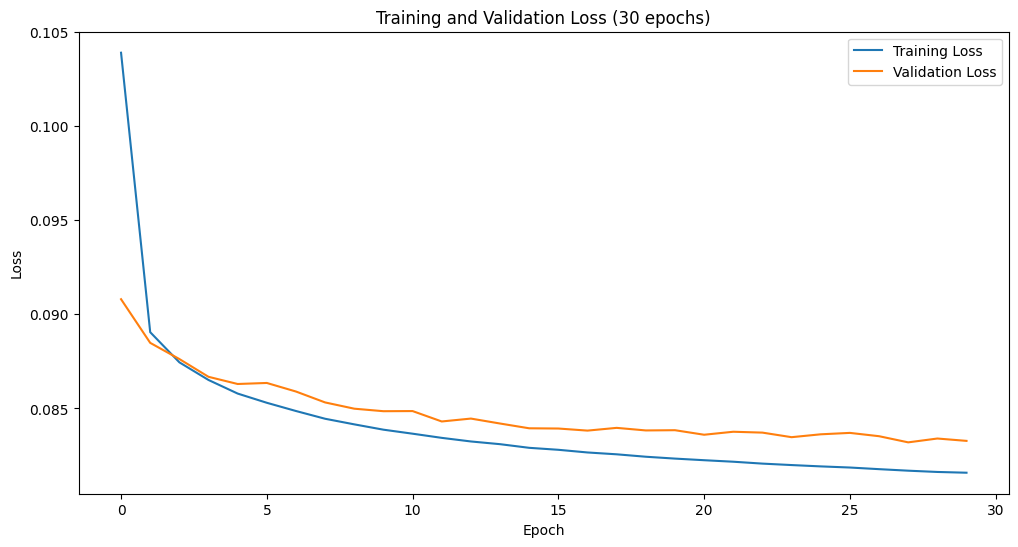

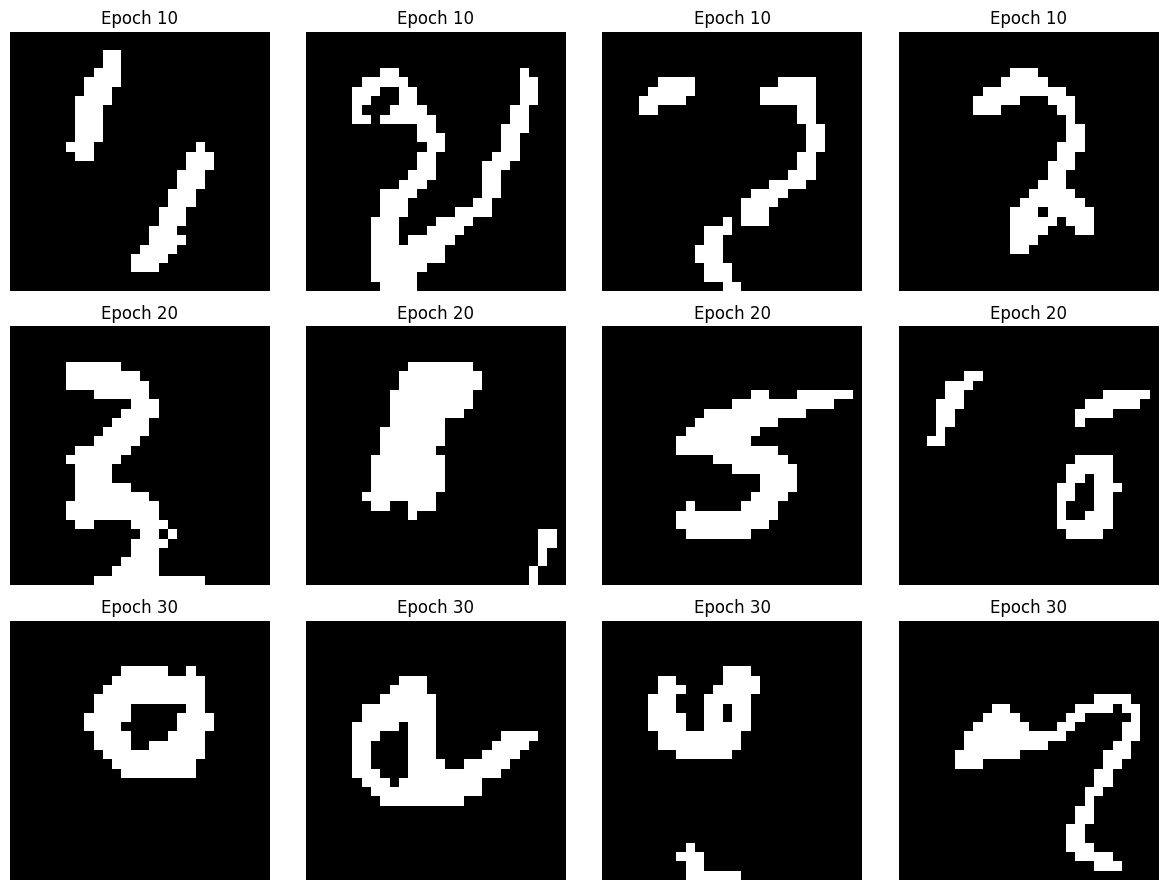

In [ ]:
# # your code here
def get_pixelcnn_model():
    return build_pixelcnn_model(input_shape=(28, 28, 1), filters=64, num_residual_blocks=5)

def generate_image(model, img_shape=(28, 28, 1)):
    """
    Generate an image pixel-by-pixel using the current state of the trained model.
    The image is generated in raster scan order.
    """
    generated = np.zeros((1, img_shape[0], img_shape[1], img_shape[2]), dtype='float32')
    for i in range(img_shape[0]):
        for j in range(img_shape[1]):
            preds = model.predict(generated, verbose=0)
            p = preds[0, i, j, 0]
            pixel_val = np.random.binomial(1, p)
            generated[0, i, j, 0] = pixel_val
    return generated[0]

model = get_pixelcnn_model()
model.compile(optimizer='adam', loss='binary_crossentropy')

total_epochs = 30
checkpoint_epochs = [10, 20, 30]
loss_history = {'loss': [], 'val_loss': []}
gen_images = {}

current_epoch = 0

for checkpoint in checkpoint_epochs:
    epochs_to_train = checkpoint - current_epoch
    print(f"\nTraining model from epoch {current_epoch + 1} to {checkpoint}...\n")
    history = model.fit(
        x_train,
        x_train,
        epochs=epochs_to_train,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    current_epoch = checkpoint

    loss_history['loss'].extend(history.history['loss'])
    loss_history['val_loss'].extend(history.history['val_loss'])

    images = [generate_image(model) for _ in range(4)]
    gen_images[checkpoint] = images

plt.figure(figsize=(12, 6))
plt.plot(loss_history['loss'], label='Training Loss')
plt.plot(loss_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (30 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

fig, axes = plt.subplots(len(checkpoint_epochs), 4, figsize=(12, 9))
for row, cp in enumerate(checkpoint_epochs):
    for col in range(4):
        axes[row, col].imshow(gen_images[cp][col].squeeze(), cmap='gray')
        axes[row, col].set_title(f"Epoch {cp}")
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

You will generate images pixel by pixel using three different trained PixelCNN models:  
- Model trained for **10 epochs**  
- Model trained for **20 epochs**  
- Model trained for **30 epochs**  

Each model will sequentially predict pixel values to generate new images.  

### To-Do:  
1. **Set up the necessary structure** for image generation.  
2. **Leverage the trained model** to infer missing pixel values step by step.  
3. **Determine pixel values** based on predictions.  
4. **Run the process with different models** and observe the outcomes.  
5. **Compare the generated images** to analyze any differences.

## (DONE ABOVE ^^)

## Reflection Questions  

After completing this part, take some time to reflect on the following questions:    


1. **How do the generated images differ across models trained for 10, 20, and 30 epochs?** What patterns or improvements do you notice with more training?

Answer: As the model trains longer, the images start looking more like real digits and less like random qr codes. After just 10 epochs, the shapes are often messy and not very digit-like. By 20 epochs, more defined structures are visible, and by 30 epochs, the digits look clearer and more recognizable. Essentially, more training helps the model learn better patterns, so the images improve and become more realistic.

2. **What role does the masked convolution play in PixelCNN?** How does it influence the way images are generated?

Answer: he masked convolution makes sure that when the model predicts a pixel, it only uses information from the pixels that came before it, in a specific order. This prevents the model from cheating by looking at the future pixels. Because of this masking, PixelCNN generates images pixel by pixel in a way that respects the order of the pixels, leading to coherent and consistent images.

<h1><b><span style="color: #9370DB;"> PixelCNN Experiments Complete!</span></h1>